# **Project: Clustering for heart disease analysis**

##### **Reference**: [amirabwd18, Azzedine Idir Aitsaid, Mohcen Chouireb, and Omar Farouk Zouak. K-Means Clustering for Heart Disease Analysis. www.kaggle.com/competitions/k-means-clustering-for-heart-disease-analysis/overview/citation](https://www.kaggle.com/competitions/k-means-clustering-for-heart-disease-analysis/overview)

--- 
## **1. Big Picture and Objectives**

- **Objective**: Using unsupervised learning techniques, find the best clustering algorithm that minimizes log loss and allows us to group patients based on common characteristics.
- **Goal**: Identify the most effective clustering technique for the given dataset.
- **Clustering algorithms to explore**: K-Means, Mini-Batch K-Means, DBSCAN, Agglomerative Clustering, Spectral Clustering, Gaussian Mixture Models (GMM), Bayesian Gaussian Mixture Models.
- **Evaluation Metric**:
    - Primary metric: Log Loss, also known as Logistic Loss or Cross-Entropy Loss, is commonly used in machine learning as a performance metric for classification problems. It quantifies the accuracy of a classifier by penalising false classifications.
    - Secondary metrics that will be used in this analysis include: Silhouette Score, Inercia, AIC, BIC.

---
## **2. Get the data**

In [22]:
import pandas as pd

df = pd.read_csv(
    "../data/clustering_for_heart_disease_analysis_project/heart_disease.csv"
)
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,915,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN
916,916,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN
917,917,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect
918,918,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN


---
## **3. Exploratory Analysis and Insights**

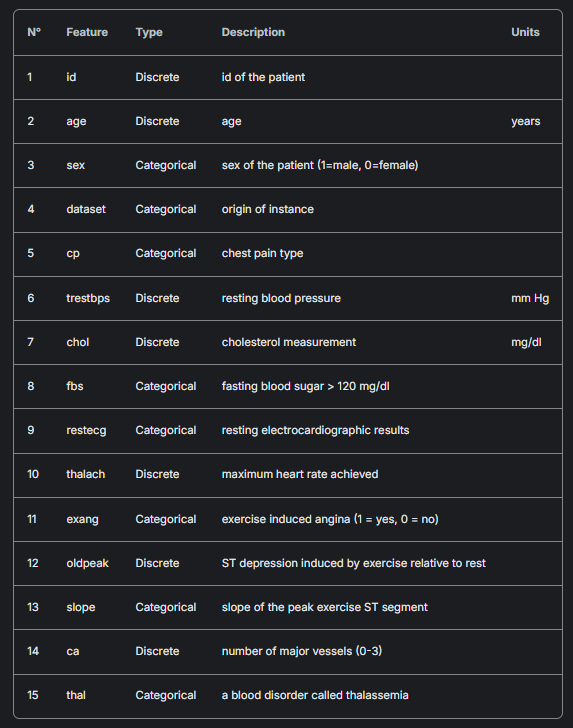

In [23]:
import pandas as pd

# Example: your heart dataframe
# df = pd.read_csv("...")

column_descriptions = {
    "id": "id of the patient",
    "age": "age (years)",
    "sex": "sex of the patient (1=male, 0=female)",
    "dataset": "origin of instance",
    "cp": "chest pain type",
    "trestbps": "resting blood pressure (mm Hg)",
    "chol": "cholesterol measurement (mg/dl)",
    "fbs": "fasting blood sugar > 120 mg/dl",
    "restecg": "resting electrocardiographic results",
    "thalch": "maximum heart rate achieved",
    "exang": "exercise induced angina (1=yes, 0=no)",
    "oldpeak": "ST depression induced by exercise relative to rest",
    "slope": "slope of the peak exercise ST segment",
    "ca": "number of major vessels (0-3)",
    "thal": "thalassemia blood disorder"
}

df.attrs["column_descriptions"] = column_descriptions


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


In [25]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,920.0,459.500000,265.725422,0.0,229.75,459.5,689.25,919.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0


In [26]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

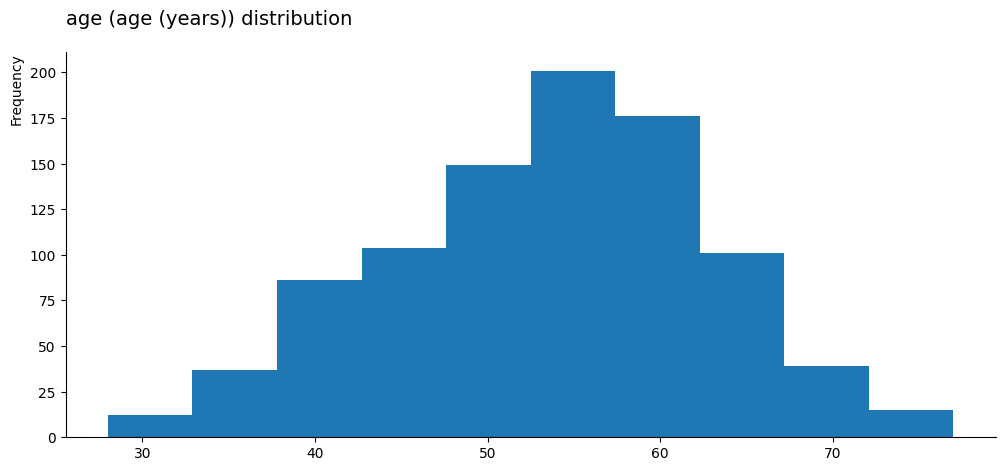

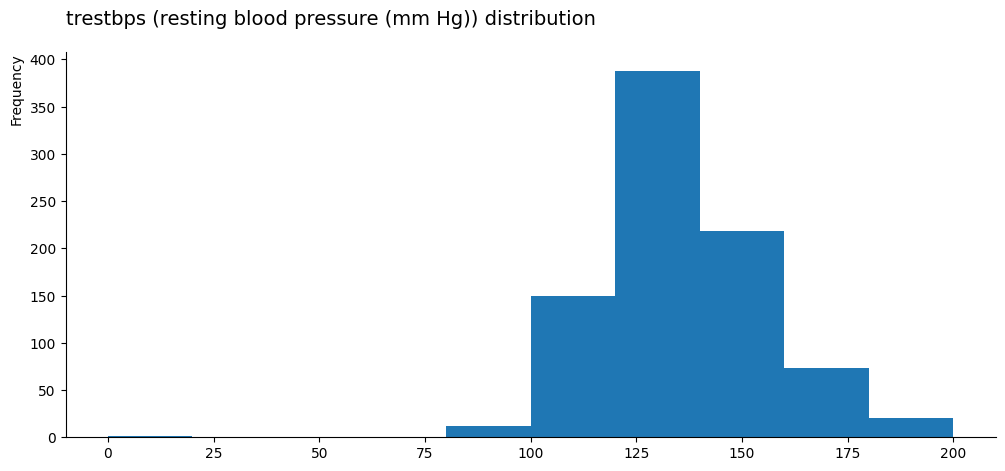

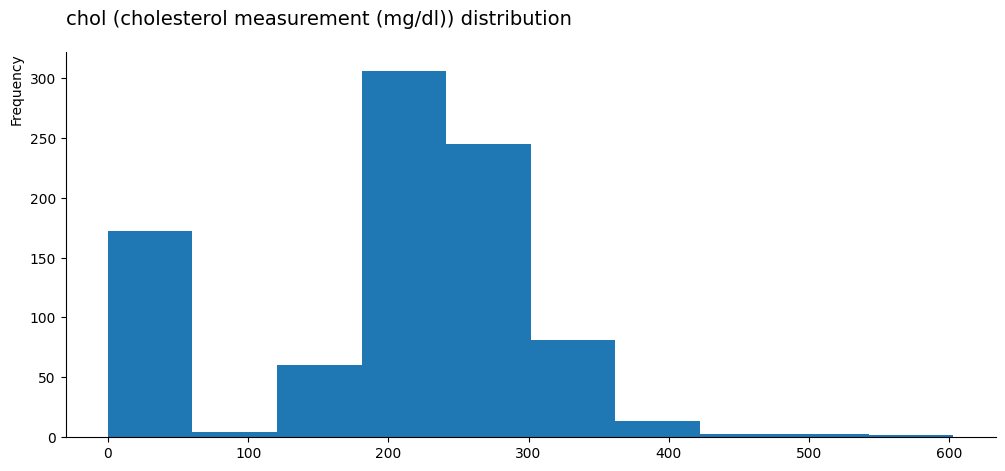

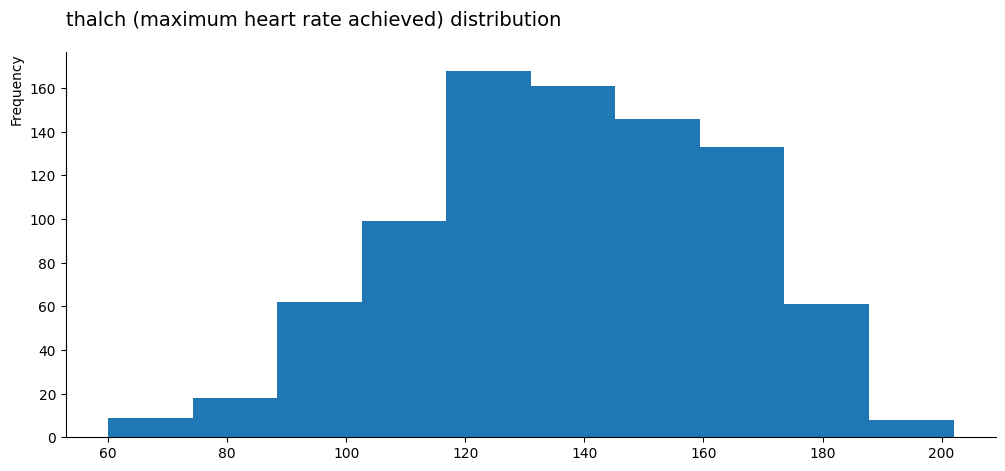

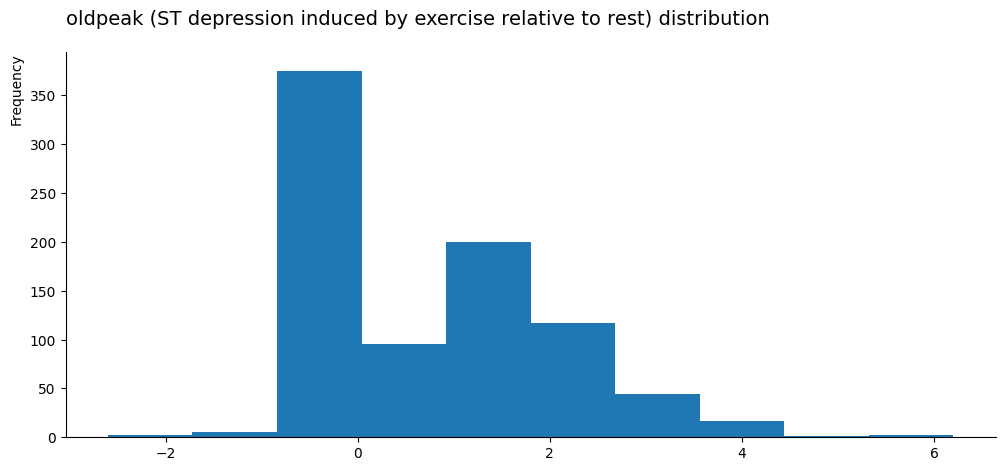

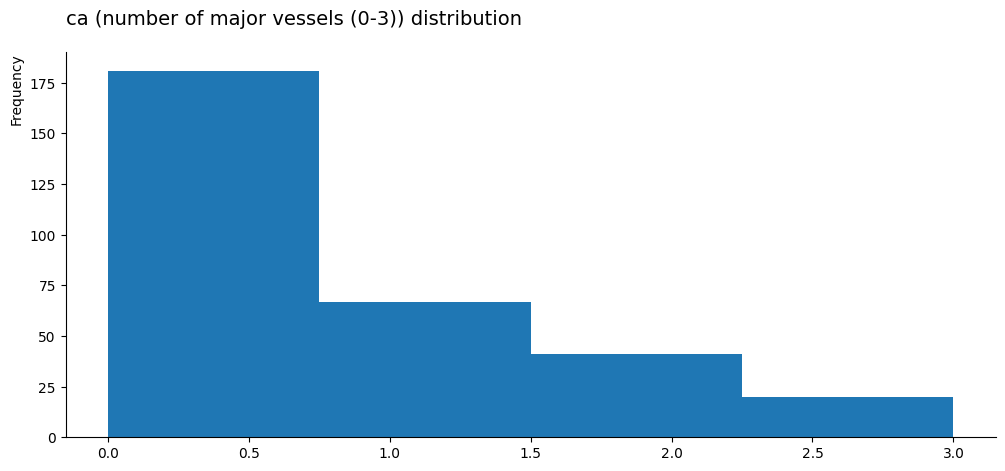

In [27]:
from matplotlib import pyplot as plt

discrete_cols = [
    col for col in df.columns
    if df[col].dtype != "object"
    and col not in ["id"]
]

for col in discrete_cols:
    bins = min(10, df[col].nunique())
    ax = df[col].plot(kind="hist", bins=bins, figsize=(12, 5))
    ax.set_title(
        f"{col} ({df.attrs['column_descriptions'].get(col, '')}) distribution",
        fontsize=14,
        loc="left",
        pad=20
    )
    ax.set_ylabel("Frequency", loc="top")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()

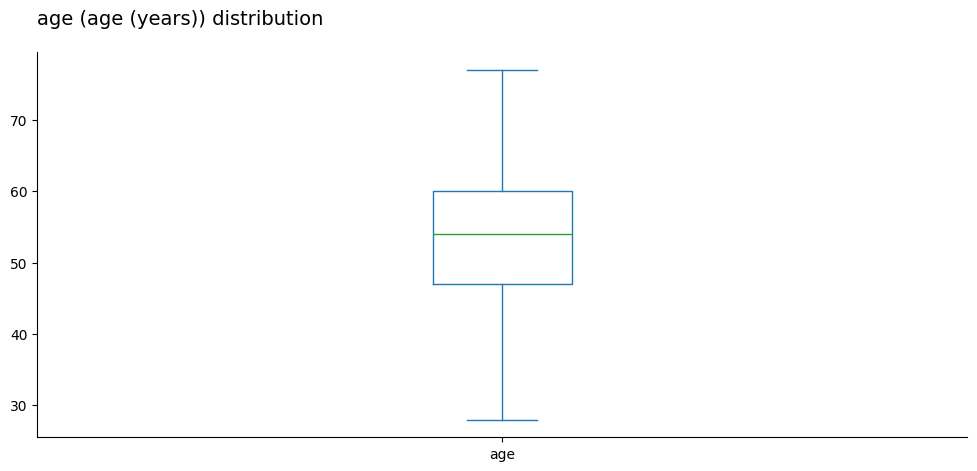

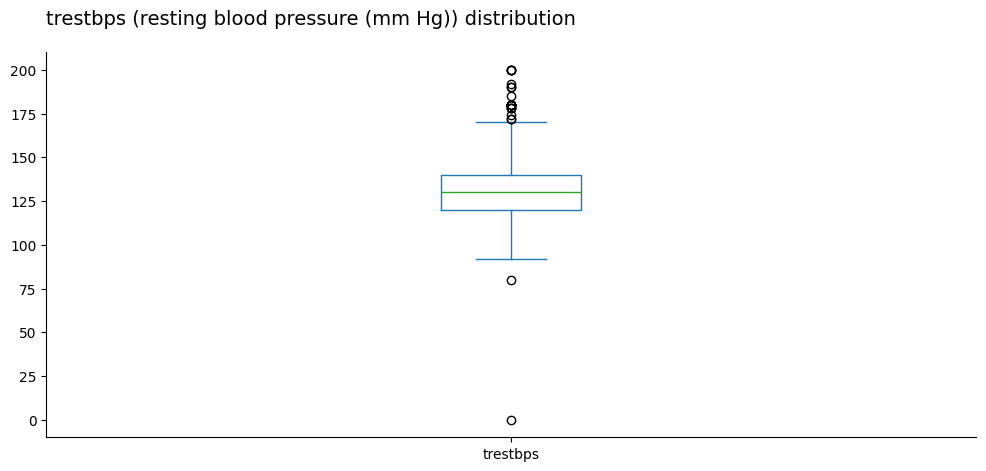

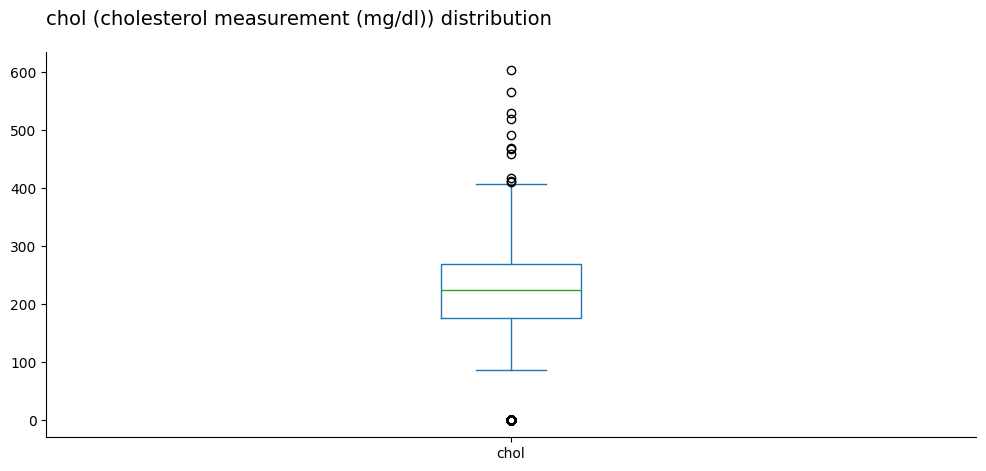

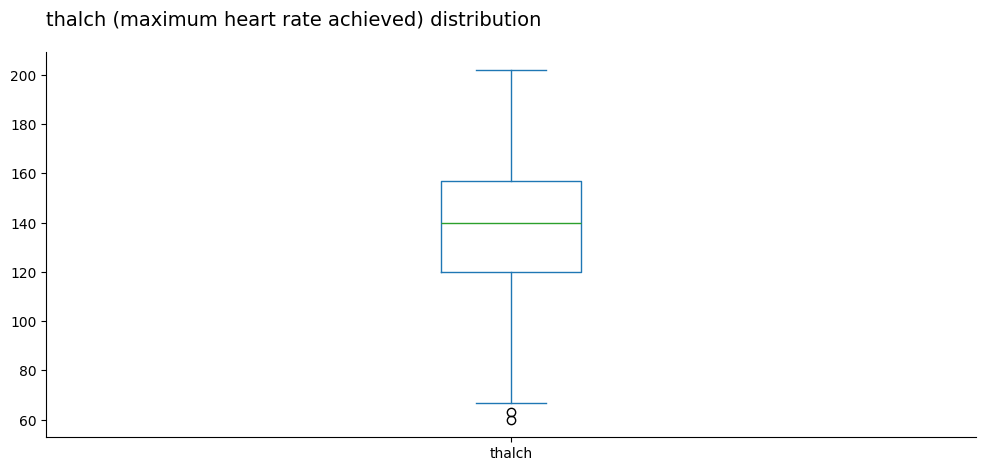

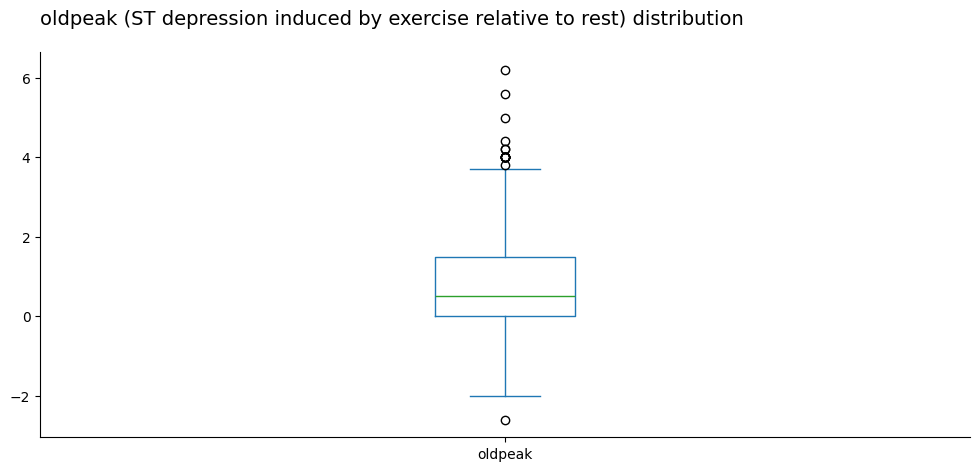

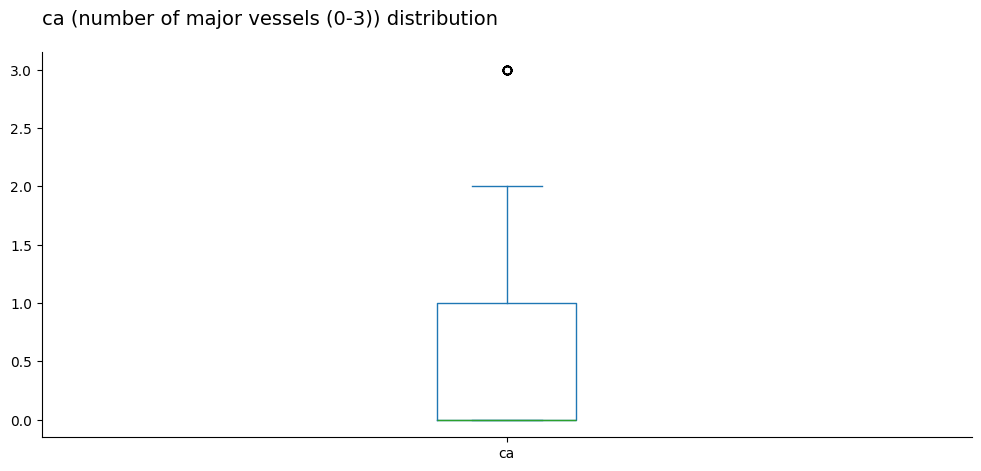

In [28]:
from matplotlib import pyplot as plt

discrete_cols = [
    col for col in df.columns
    if df[col].dtype != "object"
    and col not in ["id"]
]

for col in discrete_cols:
    bins = min(10, df[col].nunique())
    ax = df[col].plot(kind="box", figsize=(12, 5))
    ax.set_title(
        f"{col} ({df.attrs['column_descriptions'].get(col, '')}) distribution",
        fontsize=14,
        loc="left",
        pad=20
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()

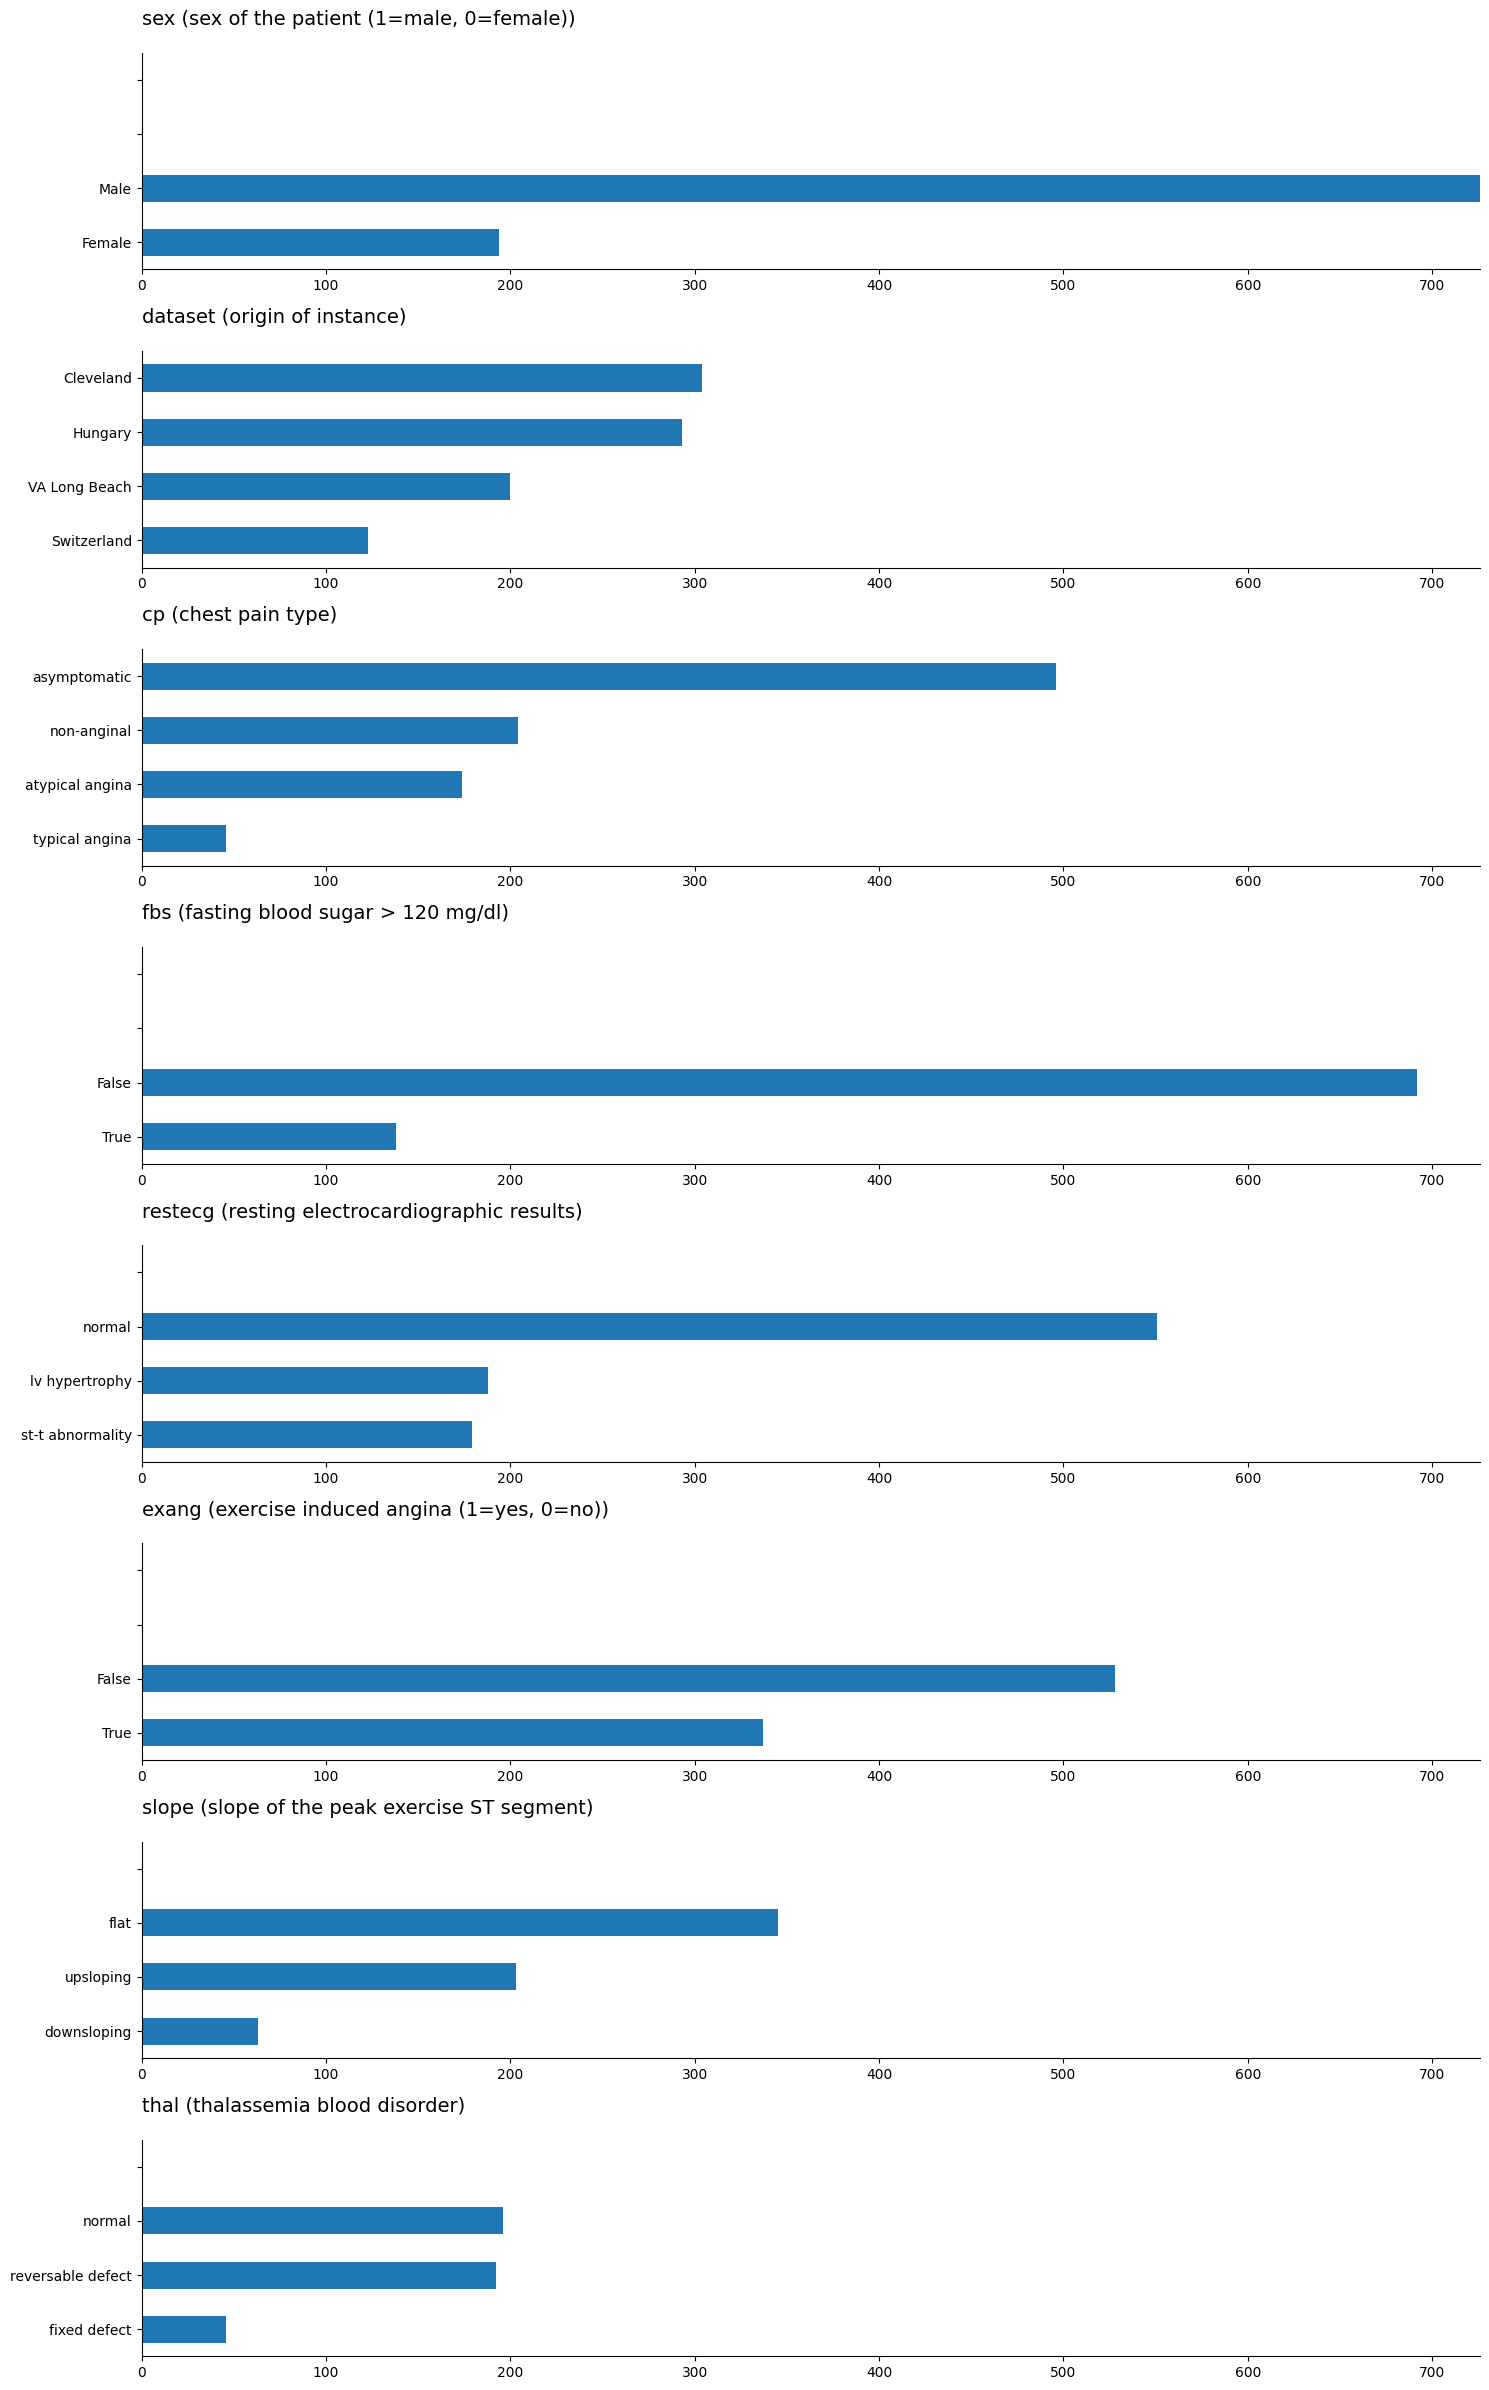

In [29]:
from matplotlib import pyplot as plt
import pandas as pd

categorical_cols = [
    col for col in df.columns if df[col].dtype == "object"
]

max_count = max(
    df[col].value_counts().max()
    for col in categorical_cols
) * 1

max_categories = max(
    df[col].nunique(dropna=True)
    for col in categorical_cols
)

fig, axes = plt.subplots(
    len(categorical_cols),
    1,
    figsize=(15, 3 * len(categorical_cols)),
    # sharex=True
)

if len(categorical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts().sort_values()

    # Pad with empty categories
    counts = counts.reindex(
        list(counts.index) +
        [f"_empty_{i}" for i in range(max_categories - len(counts))],
        fill_value=0
    )

    counts.plot(kind="barh", ax=ax)

    ax.set_xlim(0, max_count)

    # Hide the dummy labels
    labels = [
        "" if str(label).startswith("_empty_") else label
        for label in counts.index
    ]
    ax.set_yticklabels(labels)

    ax.set_title(
        f"{col} ({df.attrs['column_descriptions'].get(col, '')})",
        loc="left",
        fontsize=14, pad=20
    )
    ax.set_ylabel("")
    # if col == categorical_cols[-1]:
    # ax.set_xlabel("Frequency", loc="left")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

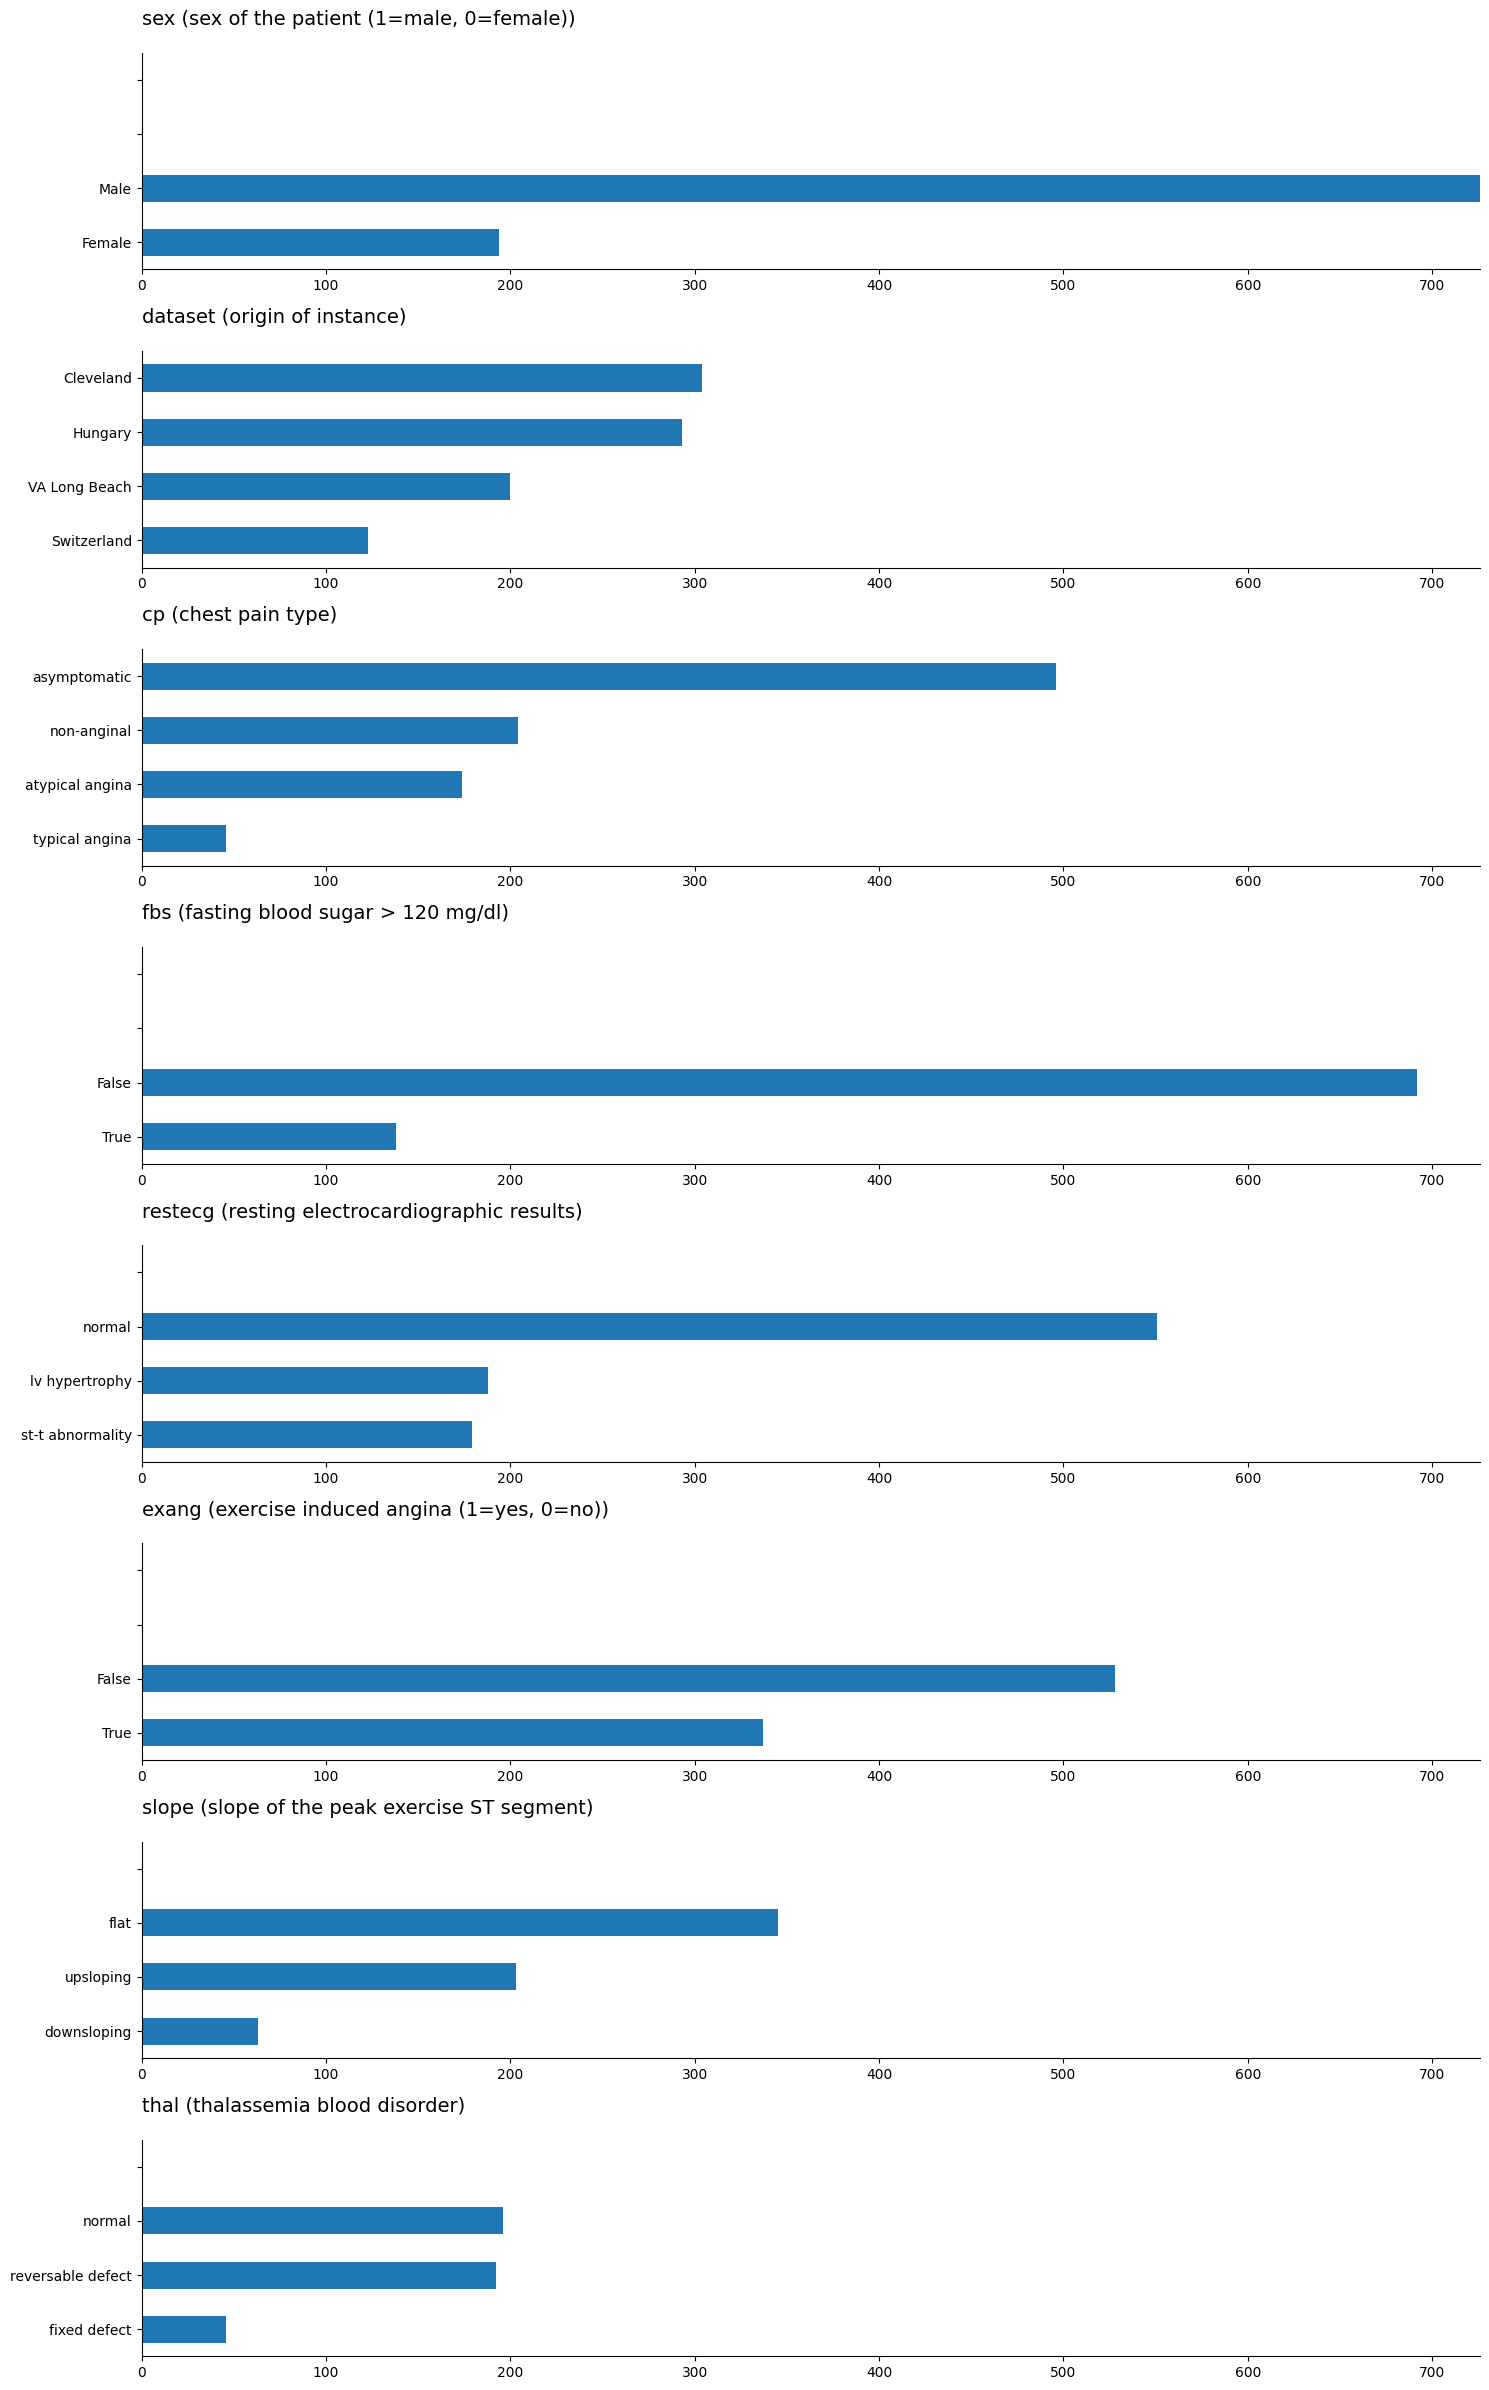

In [30]:
from matplotlib import pyplot as plt
import pandas as pd

categorical_cols = [
    col for col in df.columns if df[col].dtype == "object"
]

max_count = max(
    df[col].value_counts().max()
    for col in categorical_cols
) * 1

max_categories = max(
    df[col].nunique(dropna=True)
    for col in categorical_cols
)

fig, axes = plt.subplots(
    len(categorical_cols),
    1,
    figsize=(15, 3 * len(categorical_cols)),
    # sharex=True
)

if len(categorical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts().sort_values()

    # Pad with empty categories
    counts = counts.reindex(
        list(counts.index) +
        [f"_empty_{i}" for i in range(max_categories - len(counts))],
        fill_value=0
    )

    counts.plot(kind="barh", ax=ax)

    ax.set_xlim(0, max_count)

    # Hide the dummy labels
    labels = [
        "" if str(label).startswith("_empty_") else label
        for label in counts.index
    ]
    ax.set_yticklabels(labels)

    ax.set_title(
        f"{col} ({df.attrs['column_descriptions'].get(col, '')})",
        loc="left",
        fontsize=14, pad=20
    )
    ax.set_ylabel("")
    # if col == categorical_cols[-1]:
    # ax.set_xlabel("Frequency", loc="left")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

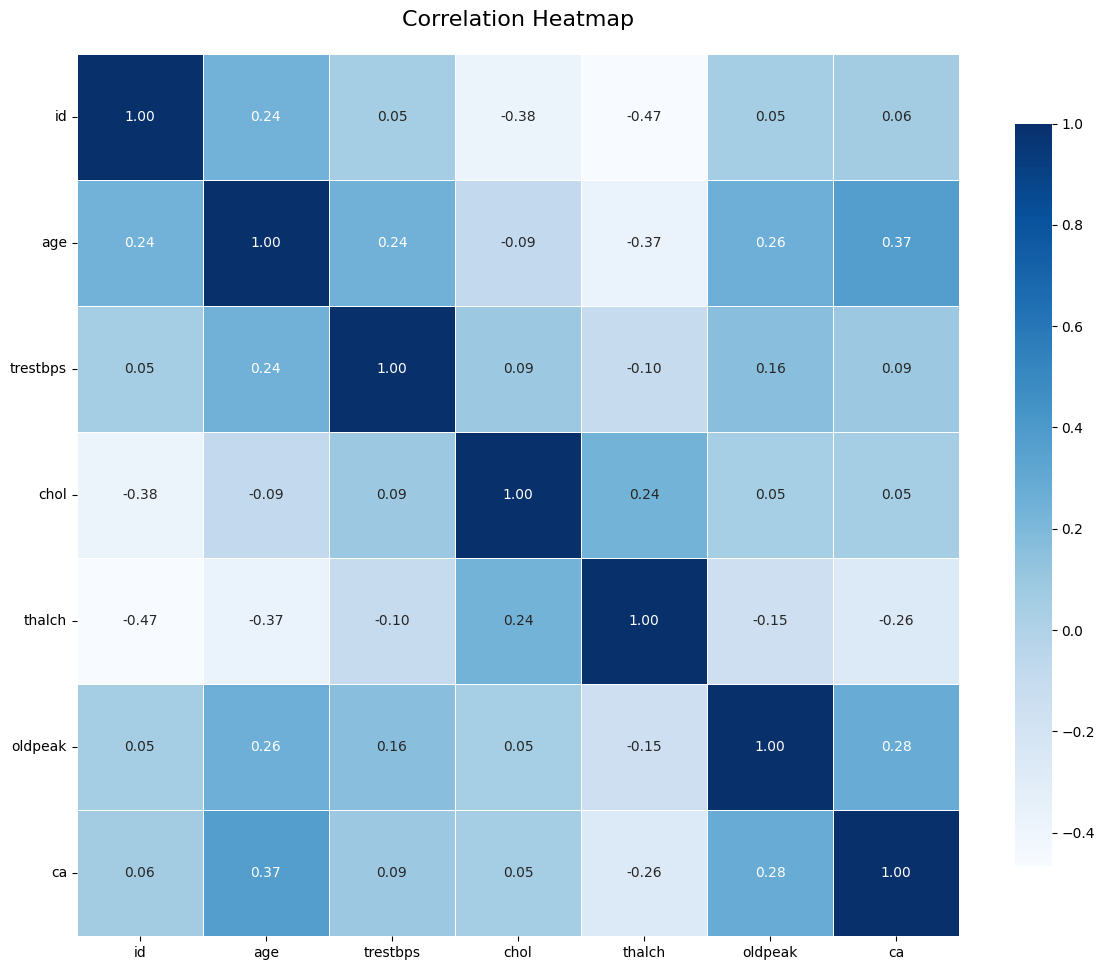

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.title("Correlation Heatmap", fontsize=16, pad=20)

sns.heatmap(
    corr,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=0, ha="center")
plt.yticks(rotation=0)  # horizontal labels

plt.tight_layout()
plt.show()

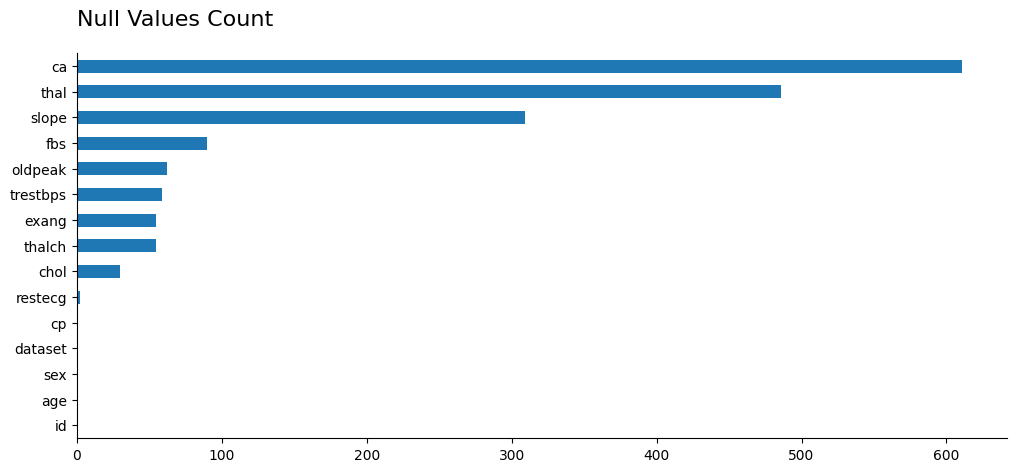

In [32]:
# Null values count
ax = df.isnull().sum().sort_values(ascending=True).plot(
    kind="barh", figsize=(12, 5), 
    )
ax.set_title(
    "Null Values Count",
    fontsize=16,
    loc="left",
    pad=20
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [33]:
# Duplicate rows count
print(f"Duplicate rows count: {df.duplicated().sum()}")

Duplicate rows count: 0
